# 06 — Feature selection

Whether attribution-guided selection improves accuracy, and whose attribution should
guide it.

| Strategy | Features kept |
|---|---|
| all | every feature from notebook 03 |
| own top-k | the model's own k highest permutation importances |
| stratified | best two of the target's own history, best one of every other family |
| Ridge weights | the k largest absolute Ridge coefficients on standardised inputs, given to every model |

k equals the size of the stratified set, so the three selection rules keep the same
number of features. Ridge weights need no post-hoc explanation: the coefficients of a
linear model on standardised inputs are its explanation. Rankings use the training-period importances of notebook 05; the
noise probe is never eligible. Each configuration is scored on the test period over
20 seeds and compared with the noise floor.

Input: `data/processed/features_*.csv`, `results/04_best_params.json`,
`results/05_importance.csv` · Output: `results/06_selection.csv`

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

BRANCHES = ["original", "seasonal", "trend"]
MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
SEEDS = range(20)

BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}
params = json.load(open("../results/04_best_params.json"))
importance = pd.read_csv("../results/05_importance.csv",
                         index_col=["branch", "model", "feature"])["importance"]


def make_model(b, name, seed):
    est = clone(BASE[name]).set_params(**params[f"{b}|{name}"])
    if name != "Ridge":
        est.set_params(random_state=seed)
    return est


def family(f):
    if f.startswith("LST"):
        return "LST"
    if f.startswith("SPEI"):
        return "drought"
    if f.startswith("month"):
        return "calendar"
    return "own history"


data = {}
for b in BRANCHES:
    df = pd.read_csv(f"../data/processed/features_{b}.csv", index_col="date", parse_dates=True)
    X, y, train = df.drop(columns=["target", "split"]), df["target"], df["split"] == "train"
    data[b] = (X[train], X[~train], y[train], y[~train])

## Selected features

In [2]:
def ranked(b, name):
    s = importance[b][name].drop("noise_probe")
    return list(s.sort_values(ascending=False).index)


def ridge_weights(b):
    Xtr, _, ytr, _ = data[b]
    model = make_model(b, "Ridge", 0).fit(Xtr, ytr)
    w = pd.Series(np.abs(model.named_steps["ridge"].coef_), index=Xtr.columns)
    return w.drop("noise_probe").sort_values(ascending=False)


def stratified(b, name):
    order = ranked(b, name)
    keep = [f for f in order if family(f) == "own history"][:2]
    for fam in ["calendar", "drought", "LST"]:
        keep += [f for f in order if family(f) == fam][:1]
    return keep


selections = {}
for b in BRANCHES:
    all_cols = list(data[b][0].columns)
    for name in MODEL_NAMES:
        strat = stratified(b, name)
        k = len(strat)
        selections[(b, name)] = {"all": all_cols,
                                 "own top-k": ranked(b, name)[:k],
                                 "stratified": strat,
                                 "Ridge weights": list(ridge_weights(b).index[:k])}

short = lambda cols: ", ".join(c.replace("NDVI_", "").replace("NDVI", "") for c in cols)
for b in BRANCHES:
    print(f"\n{b}   Ridge |weights|: " + ", ".join(
        f"{short([f])} {w:.3f}" for f, w in ridge_weights(b).items()))
    for name in MODEL_NAMES:
        for strategy in ["own top-k", "stratified", "Ridge weights"]:
            print(f"  {name:12s} {strategy:11s} {short(selections[(b, name)][strategy])}")


original   Ridge |weights|: lag1 0.075, lag12 0.036, lag24 0.033, LST_lag1 0.027, lag14 0.026, lag23 0.021, lag3 0.017, SPEI_6_lag1 0.013, month_cos 0.006, lag18 0.002, lag11 0.001
  XGBoost      own top-k   LST_lag1, lag1, lag24, lag11, lag23
  XGBoost      stratified  lag1, lag24, month_cos, SPEI_6_lag1, LST_lag1
  XGBoost      Ridge weights lag1, lag12, lag24, LST_lag1, lag14
  RandomForest own top-k   LST_lag1, lag24, lag1, lag12, lag18
  RandomForest stratified  lag24, lag1, month_cos, SPEI_6_lag1, LST_lag1
  RandomForest Ridge weights lag1, lag12, lag24, LST_lag1, lag14
  Ridge        own top-k   lag1, lag24, lag12, LST_lag1, lag3
  Ridge        stratified  lag1, lag24, month_cos, SPEI_6_lag1, LST_lag1
  Ridge        Ridge weights lag1, lag12, lag24, LST_lag1, lag14

seasonal   Ridge |weights|: S_lag1 0.060, S_lag24 0.048, S_lag14 0.039, S_lag12 0.034, LST_S_lag1 0.032, month_cos 0.024, S_lag3 0.021, S_lag18 0.018, S_roll12 0.016, S_lag23 0.014, SPEI_24_S_lag1 0.010, SPEI_6_S_la

## Test-period accuracy

In [3]:
rows = []
for b in BRANCHES:
    Xtr, Xte, ytr, yte = data[b]
    for name in MODEL_NAMES:
        seeds = [0] if name == "Ridge" else SEEDS
        for strategy, cols in selections[(b, name)].items():
            preds = [make_model(b, name, s).fit(Xtr[cols], ytr).predict(Xte[cols]) for s in seeds]
            r2 = [r2_score(yte, p) for p in preds]
            rmse = [np.sqrt(mean_squared_error(yte, p)) for p in preds]
            rows.append(dict(branch=b, model=name, strategy=strategy, k=len(cols),
                             RMSE_mean=np.mean(rmse), RMSE_sd=np.std(rmse),
                             R2_mean=np.mean(r2), R2_sd=np.std(r2)))

results = pd.DataFrame(rows)
base = results[results.strategy == "all"].set_index(["branch", "model"])
results["delta"] = results.apply(
    lambda r: r.R2_mean - base.loc[(r.branch, r.model), "R2_mean"], axis=1)
results["delta_RMSE"] = results.apply(
    lambda r: r.RMSE_mean - base.loc[(r.branch, r.model), "RMSE_mean"], axis=1)
results["floor"] = results.apply(
    lambda r: max(r.R2_sd, base.loc[(r.branch, r.model), "R2_sd"]), axis=1)
results["beyond_floor"] = (results.delta.abs() > 2 * results.floor) & (results.floor > 0) \
                          | ((results.floor == 0) & (results.delta.abs() > 0.005))

for b in BRANCHES:
    for col, label, ref in [("delta_RMSE", "RMSE", "RMSE_mean"), ("delta", "R2", "R2_mean")]:
        t = results[results.branch == b].pivot(index="strategy", columns="model", values=col)
        t = t.loc[["own top-k", "stratified", "Ridge weights"], MODEL_NAMES]
        print(f"\n{b}: change in test {label} against all features (all: "
              + ", ".join(f"{m} {base.loc[(b, m), ref]:.4f}" for m in MODEL_NAMES) + ")")
        print(t.round(4).to_string())


original: change in test RMSE against all features (all: XGBoost 0.0550, RandomForest 0.0581, Ridge 0.0584)
model          XGBoost  RandomForest   Ridge
strategy                                    
own top-k       0.0013        0.0010  0.0022
stratified      0.0006       -0.0034  0.0040
Ridge weights   0.0026        0.0009  0.0082

original: change in test R2 against all features (all: XGBoost 0.8778, RandomForest 0.8633, Ridge 0.8619)
model          XGBoost  RandomForest   Ridge
strategy                                    
own top-k      -0.0058       -0.0046 -0.0104
stratified     -0.0026        0.0155 -0.0195
Ridge weights  -0.0118       -0.0044 -0.0413

seasonal: change in test RMSE against all features (all: XGBoost 0.0561, RandomForest 0.0558, Ridge 0.0640)
model          XGBoost  RandomForest   Ridge
strategy                                    
own top-k       0.0038        0.0030  0.0021
stratified      0.0031       -0.0008  0.0005
Ridge weights   0.0025        0.0021  0.0021


A difference is counted as real only when it exceeds twice the larger seed-to-seed
standard deviation of the two configurations. Ridge is deterministic, so for Ridge a
threshold of 0.005 is used.

In [4]:
print(results[["branch", "model", "strategy", "k", "RMSE_mean", "RMSE_sd", "R2_mean", "R2_sd",
               "delta", "beyond_floor"]]
      .round(4).to_string(index=False))

  branch        model      strategy  k  RMSE_mean  RMSE_sd  R2_mean  R2_sd   delta  beyond_floor
original      XGBoost           all 12     0.0550   0.0005   0.8778 0.0023  0.0000         False
original      XGBoost     own top-k  5     0.0563   0.0004   0.8721 0.0018 -0.0058          True
original      XGBoost    stratified  5     0.0556   0.0005   0.8752 0.0022 -0.0026         False
original      XGBoost Ridge weights  5     0.0576   0.0003   0.8661 0.0012 -0.0118          True
original RandomForest           all 12     0.0581   0.0004   0.8633 0.0020  0.0000         False
original RandomForest     own top-k  5     0.0591   0.0004   0.8587 0.0018 -0.0046          True
original RandomForest    stratified  5     0.0547   0.0004   0.8788 0.0018  0.0155          True
original RandomForest Ridge weights  5     0.0591   0.0003   0.8589 0.0014 -0.0044          True
original        Ridge           all 12     0.0584   0.0000   0.8619 0.0000  0.0000         False
original        Ridge     own 

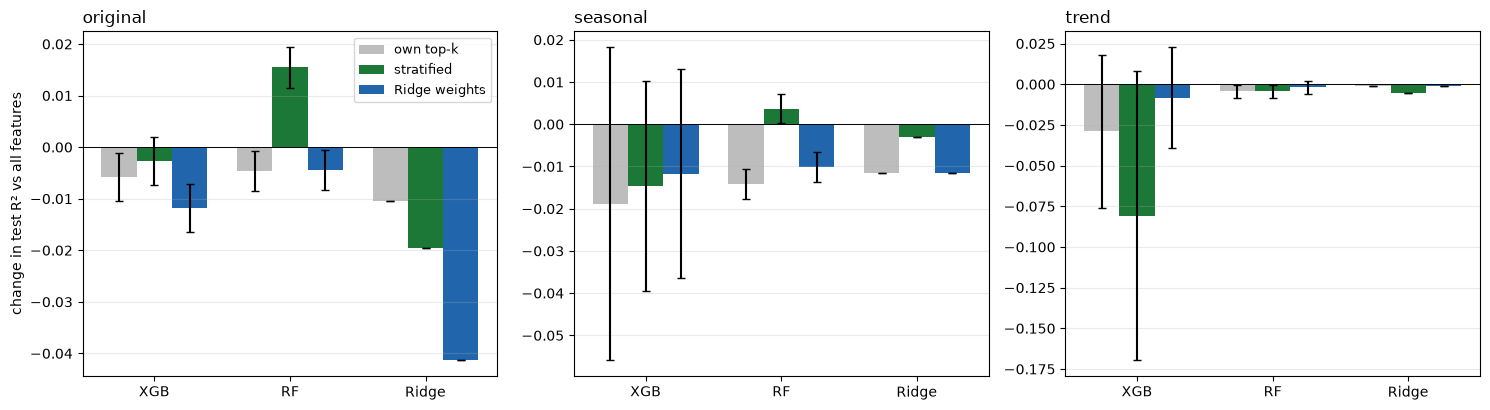

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
strategies = ["own top-k", "stratified", "Ridge weights"]
colors = {"own top-k": "#bdbdbd", "stratified": "#1b7837", "Ridge weights": "#2166ac"}
for ax, b in zip(axes, BRANCHES):
    sub = results[(results.branch == b) & (results.strategy != "all")]
    for i, strategy in enumerate(strategies):
        s = sub[sub.strategy == strategy].set_index("model").reindex(MODEL_NAMES)
        x = np.arange(3) + (i - 1) * 0.26
        ax.bar(x, s.delta, width=0.26, color=colors[strategy], label=strategy,
               yerr=2 * s.floor, capsize=3)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_xticks(range(3), ["XGB", "RF", "Ridge"])
    ax.set_title(b, loc="left")
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel("change in test R² vs all features")
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig("../figures/06_selection.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [6]:
results.to_csv("../results/06_selection.csv", index=False)
json.dump({f"{b}|{m}": sel for (b, m), sel in selections.items()},
          open("../results/06_selected_features.json", "w"), indent=2)
print("saved")

saved
